**Exploratory Data Analysis(EDA) and Machine Learning on Agricultural Yield Dataset ASSIGNMENT**

In [ ]:
!pip install pandas --quiet

In [31]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Load Dataset
df = pd.read_csv("agriculture_yield_dataset.csv")
print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


**PART A: UNDERSTANDING THE DATASET**

In [ ]:
#Q1. Dataset Overview
print("DATASET OVERVIEW:")
print(df.head())
print("\nDataset Information:")
print(df.info())
df.columns = ['rainfall_mm','temperature_c','fertilizer_kg','irrigation_hours','soil_ph','crop_type','soil_type','yield_ton_per_hectare']
df['rainfall_mm'] = pd.to_numeric(df['rainfall_mm'])
df['temperature_c'] = pd.to_numeric(df['temperature_c'])
df['fertilizer_kg'] = pd.to_numeric(df['fertilizer_kg'])
df['irrigation_hours'] = pd.to_numeric(df['irrigation_hours'])
df['soil_ph'] = pd.to_numeric(df['soil_ph'])
df['yield_ton_per_hectare'] = pd.to_numeric(df['yield_ton_per_hectare'])
print("\nDataset Description:")
print(df.describe())
print("\nDataset Shape(Rows and Columns):")
print(df.shape)
print("\nDataset Columns Names:")
print(df.columns)
print("\nRESULT:")
print(df.head())
print("\nFirst 10 Records of the Dataset:")
print(df.head(10))
print("\nFirst 10 Records of the Dataset:")
print(df.head(10))

DATASET OVERVIEW:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

  crop_type soil_type  yield_ton_per_hectare  
0     Maize     Loamy                   5.92  
1     Maize     Sandy                   6.24  
2     Wheat     Sandy                   4.77  
3     Maize     Loamy                   4.04  
4    Cotton      Clay                   5.17  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rainfall_mm 

In [ ]:
df

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
...,...,...,...,...,...,...,...,...
1495,473.8,32.3,65.0,3.6,5.8,Cotton,Sandy,3.28
1496,825.9,18.4,200.8,9.9,6.7,Cotton,Sandy,5.16
1497,329.3,23.3,90.3,7.7,7.0,Soybean,Sandy,3.60
1498,801.7,28.6,204.1,3.4,6.9,Rice,Sandy,5.03


In [ ]:
#Q2. Datatypes and Missing values
print("\nDATA TYPES OF EACH COLUMN:")
print(df.dtypes)
print("\nMISSING VALUES:")
print(df.isnull().sum())
print("\nUNIQUE VALUES:")
print(df.nunique())
print("\nCOLUMNS WITH MISSING VALUES:")
print(df.columns[df.isnull().any()])


DATA TYPES OF EACH COLUMN:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

MISSING VALUES:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

UNIQUE VALUES:
rainfall_mm              1389
temperature_c             201
fertilizer_kg            1044
irrigation_hours           91
soil_ph                    26
crop_type                   5
soil_type                   3
yield_ton_per_hectare     403
dtype: int64

COLUMNS WITH MISSING VALUES:
Index([], dtype='object')


In [ ]:
#Q3. Descriptive Statistics
print("\nDESCRIPTIVE STATISTICS:")
print(df.describe())
means = df.describe().loc['mean']
stds = df.describe().loc['std']
print("\nMEAN:")
print(means)
print("\nSTANDARD DEVIATION:")
print(stds)
print("\nFeature with the Highest Mean:")
print(means.idxmax(), "=", means.max())
print("\nFeature with the Highest Standard Deviation:")
print(stds.idxmax(), "=", stds.max())


DESCRIPTIVE STATISTICS:
       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.7

**PART B: EXPLORATORY DATA ANALYSIS (EDA)**

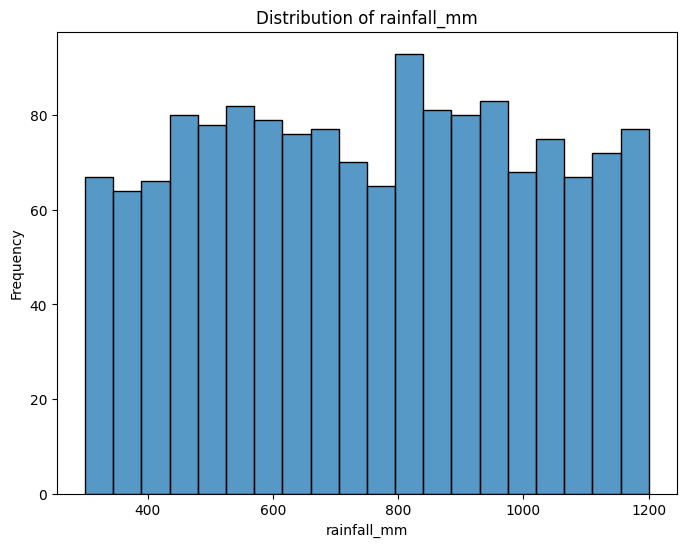

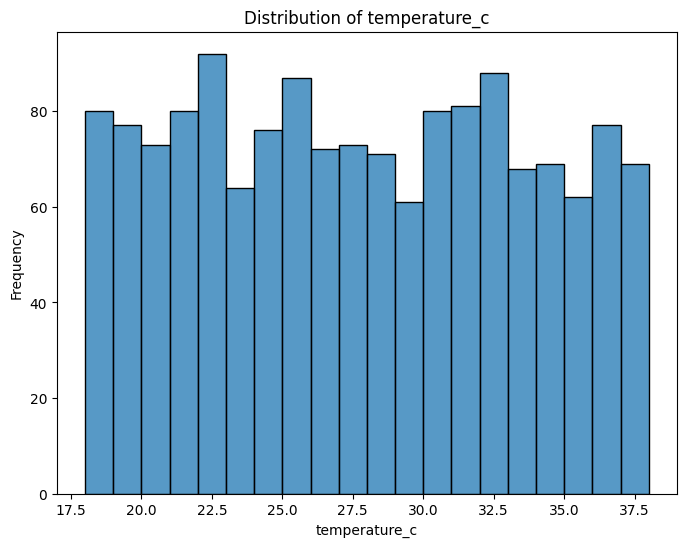

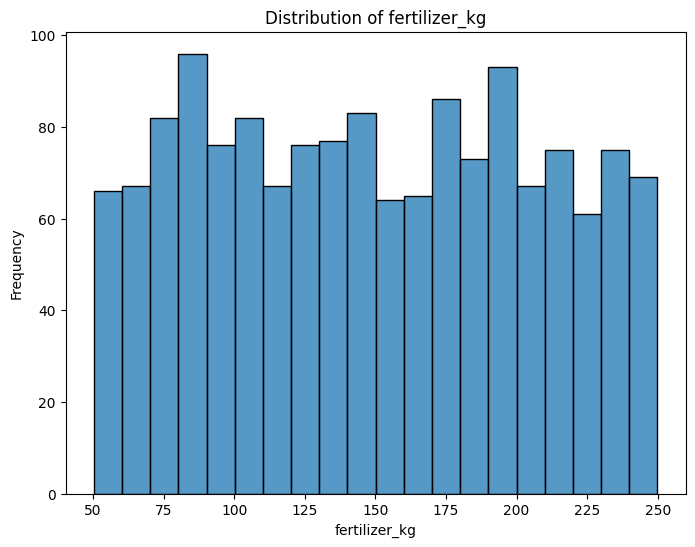

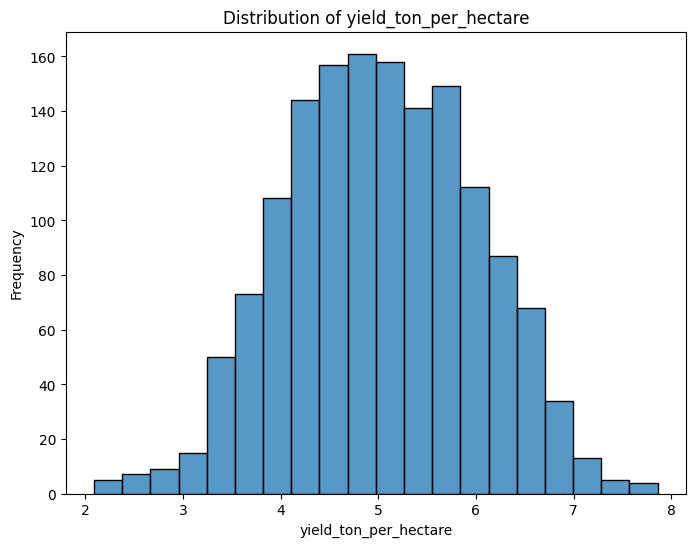

In [32]:
#Q4. Distribution Analysis
features = [
    'rainfall_mm',
    'temperature_c',
    'fertilizer_kg',
    'yield_ton_per_hectare'
]
for feature in features:
    plt.figure(figsize=(8,6))
    sns.histplot(df[feature], bins=20)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {feature}')
    plt.show()

**Q4. DISTRIBUTION ANALYSIS**

**OBSERVATIONS:**
1. **rainfall_mm**
*   The rainfall values are spread fairly evenly between approximately **300 mm and 1200 mm**.
*   The distribution appears roughly uniform with no strong skewness.
*   No significant outliers are visible; rainfall measurements are distributed across the entire range.


2. **temperature_c**
*   Temperature values range from about **15 degree celsius to 40 degree celsius**.
*   The histogram shows a nearly uniform distribution across the range.
*   There are no obvious extreme values or outliers.


3. **fertilizer_kg**
*   Fertilizer usage ranges from approximately **50 kg to 250 kg**.
*   The distribution is relatively even, indicating that different fertilizer amounts were sampled uniformly.
*   No noticeable skewness or unusual clusters are observed.


4. **yield_ton_per_hectare**
*   Yield values are concentrated around **4-6 tons per hectare**.
*   The distribution is approximately bell-shaped(close to normal).
*   There are very few extreme values, suggesting the dataset contains minimal outliers.


























Crop Frequencies:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


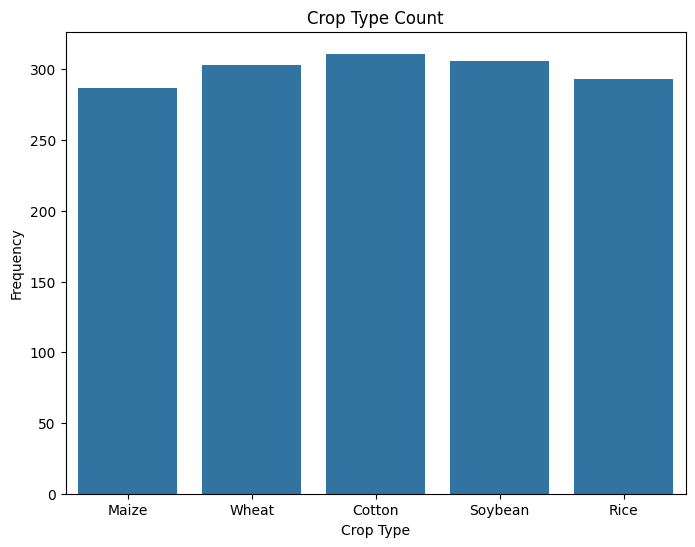


Most Frequent Crop Type:
Cotton = 311


In [ ]:
#Q5. Crop Type Analysis
crop_counts = df['crop_type'].value_counts()
print("\nCrop Frequencies:")
print(crop_counts)
plt.figure(figsize=(8,6))
sns.countplot(x='crop_type', data=df)
plt.xlabel('Crop Type')
plt.ylabel('Frequency')
plt.title('Crop Type Count')
plt.show()
print("\nMost Frequent Crop Type:")
print(crop_counts.idxmax(), "=", crop_counts.max())


Soil Frequencies:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


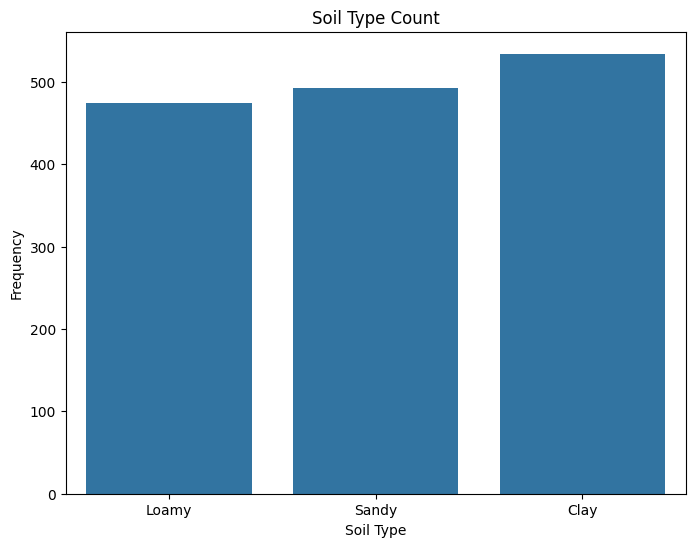


Most Frequent Soil Type:
Clay = 534


In [ ]:
#Q6. Soil Type Analysis
soil_counts = df['soil_type'].value_counts()
print("\nSoil Frequencies:")
print(soil_counts)
plt.figure(figsize=(8,6))
sns.countplot(x='soil_type', data=df)
plt.xlabel('Soil Type')
plt.ylabel('Frequency')
plt.title('Soil Type Count')
plt.show()
print("\nMost Frequent Soil Type:")
print(soil_counts.idxmax(), "=", soil_counts.max())

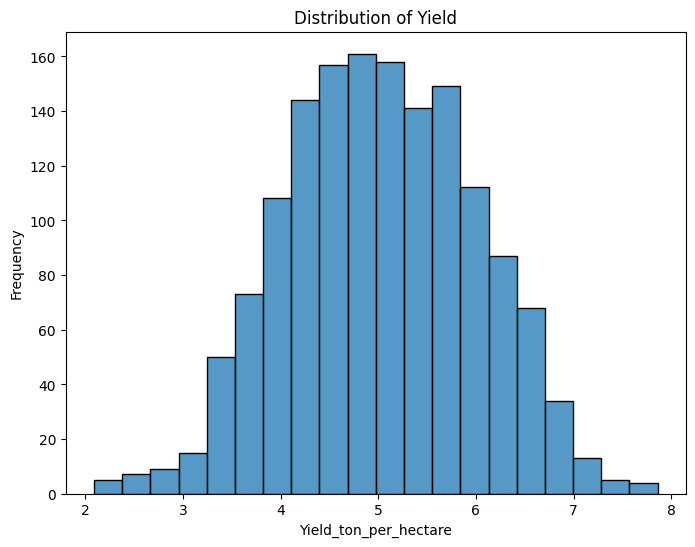

In [ ]:
#Q7. Yield Distribution
plt.figure(figsize=(8,6))
sns.histplot(df['yield_ton_per_hectare'], bins=20)
plt.xlabel('Yield_ton_per_hectare')
plt.ylabel('Frequency')
plt.title('Distribution of Yield')
plt.show()

**Q7. YIELD DISTRIBUTION**

**OBSERVATIONS:**
*   Yield values are concentrated around the middle range(~5 tons/hectare).
*   Distribution is approximately normal.
*   No strong/extreme outliers are evident.

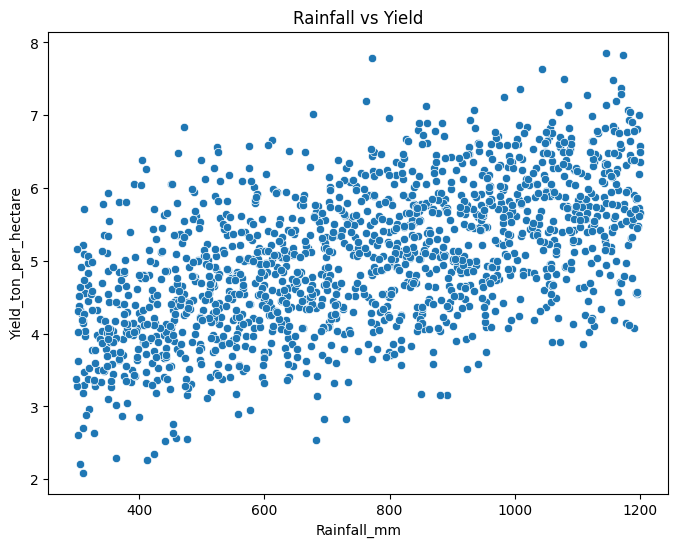

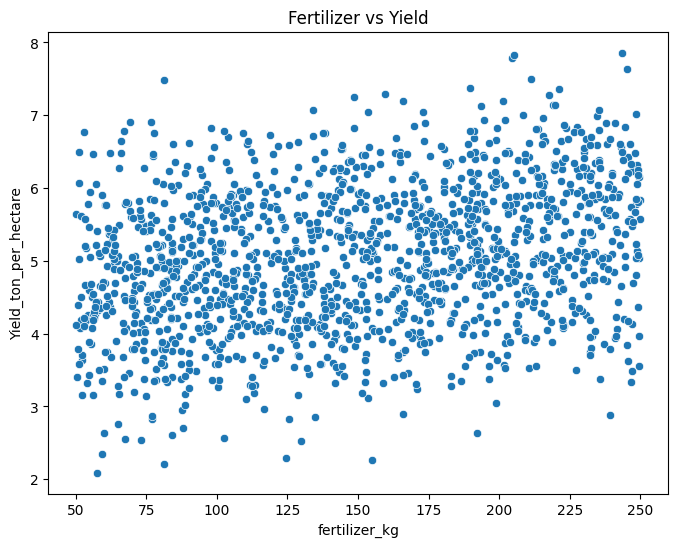


Correlation between Rainfall and Yield:
0.5537042408932247

Correlation between Fertilizer and Yield:
0.27804258886930494


In [ ]:
#Q8. Scatter Plot Analysis
plt.figure(figsize=(8,6))
sns.scatterplot(x='rainfall_mm', y='yield_ton_per_hectare', data=df)
plt.xlabel('Rainfall_mm')
plt.ylabel('Yield_ton_per_hectare')
plt.title('Rainfall vs Yield')
plt.show()
plt.figure(figsize=(8,6))
sns.scatterplot(x='fertilizer_kg', y='yield_ton_per_hectare', data=df)
plt.xlabel('fertilizer_kg')
plt.ylabel('Yield_ton_per_hectare')
plt.title('Fertilizer vs Yield')
plt.show()
corr_rainfall = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
corr_fertilizer = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])
print("\nCorrelation between Rainfall and Yield:")
print(corr_rainfall)
print("\nCorrelation between Fertilizer and Yield:")
print(corr_fertilizer)

**Q8. SCATTER PLOT ANALYSIS**

**Stronger Relationship**


*   rainfall_mm vs yield -> **stronger relationship**
*   fertilizer_kg vs yield -> weaker relationship




Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412   

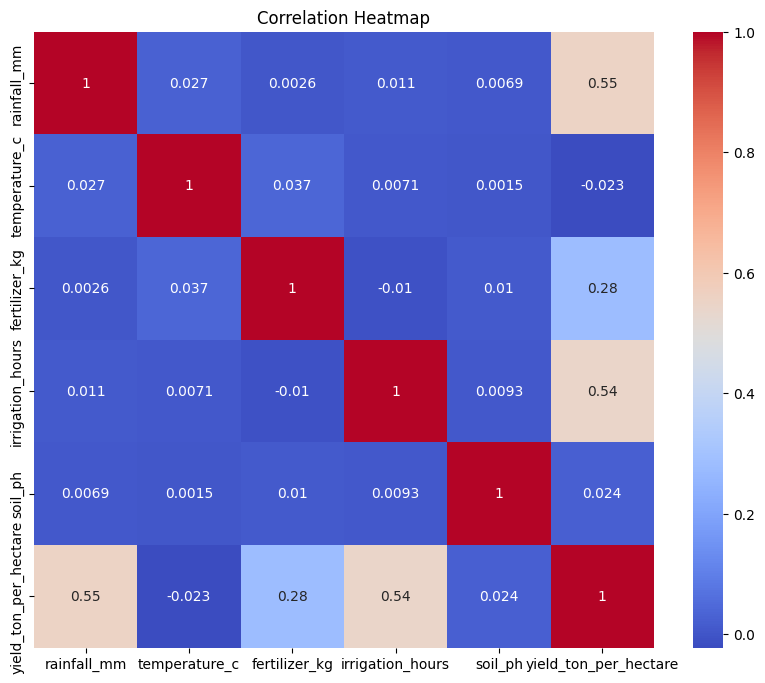


Correlation with Yield:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [ ]:
#Q9. Correlation Analysis
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
yield_corr = correlation_matrix['yield_ton_per_hectare'].sort_values(ascending=False)
print("\nCorrelation with Yield:")
print(yield_corr)

In [ ]:
#Q10. Group-Based Analysis
crop_yield_avg = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print("\nAverage Yield by Crop Type:")
print(crop_yield_avg)
soil_yield_avg = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print("\nAverage Yield by Soil Type:")
print(soil_yield_avg)
print("\nCrop with the Highest Average Yield:")
print(crop_yield_avg.idxmax(), "=", crop_yield_avg.max())
print("\nSoil with the Highest Average Yield:")
print(soil_yield_avg.idxmax(), "=", soil_yield_avg.max())


Average Yield by Crop Type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop with the Highest Average Yield:
Rice = 5.494744027303755

Soil with the Highest Average Yield:
Loamy = 5.366518987341772


**PART C: DATA PREPARATION**

In [39]:
#Q11. Feature Encoding
categorical_cols = ['crop_type', 'soil_type']
print("\nCategorical Columns:")
print(categorical_cols)

print("\nCategorical Columns:")
cols = df.select_dtypes(include=['object']).columns
print(cols)
#One-Hot Encoded Columns
df_encoded = pd.get_dummies(df,
                            columns=cols,
                            dtype=int
                            )
original_cols = set(df.columns)
encoded_cols = [col for col in df_encoded.columns if col not in original_cols]
print("\nOne-Hot Encoded Columns:")
for col in encoded_cols:
  print(col)
print("\nFirst 5 Rows of Encoded Dataset:")
print(df_encoded.head())


Categorical Columns:
['crop_type', 'soil_type']

Categorical Columns:
Index(['crop_type', 'soil_type'], dtype='object')

One-Hot Encoded Columns:
crop_type_Cotton
crop_type_Maize
crop_type_Rice
crop_type_Soybean
crop_type_Wheat
soil_type_Clay
soil_type_Loamy
soil_type_Sandy

First 5 Rows of Encoded Dataset:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92                 0                1               0   
1                   6.24                 0                1               0   
2 

In [ ]:
#Q12. Feature Selection
X = df_encoded.drop('yield_ton_per_hectare',
                    axis=1
)
y = df_encoded['yield_ton_per_hectare']
print("\nInput Features (X):")
print(X.columns)
print("\nTarget Variable (y):")
print(y.head())


Input Features (X):
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type_Cotton', 'crop_type_Maize', 'crop_type_Rice',
       'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Clay',
       'soil_type_Loamy', 'soil_type_Sandy'],
      dtype='object')

Target Variable (y):
0    5.92
1    6.24
2    4.77
3    4.04
4    5.17
Name: yield_ton_per_hectare, dtype: float64


**PART D: MACHINE LEARNING**

In [ ]:
#Q13. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("\nTraining Data Shape:")
print("X_train Shape:",X_train.shape,"\ny_train Shape:", y_train.shape)
print("\nTesting Data Shape:")
print("X_test Shape:",X_test.shape, "\ny_test Shape:",y_test.shape)


Training Data Shape:
X_train Shape: (1200, 13) 
y_train Shape: (1200,)

Testing Data Shape:
X_test Shape: (300, 13) 
y_test Shape: (300,)


In [ ]:
#Q14. Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
print("\nLinear Regression Model Trained Successfully.")
print("\nModel Intercept:")
print(model.intercept_)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
print("\nModel Coefficients:")
print(coef_df)
print("\nTop 3 Most Important Features:")
print(coef_df.head(3))
print("\nTop 3 Least Important Features:")
print(coef_df.tail(3))
print("\nFeature with Highest Positive Coefficient:")
print(coef_df[coef_df['Coefficient'] == coef_df['Coefficient'].max()])
print("\nFeature with Highest Negative Coefficient:")
print(coef_df[coef_df['Coefficient'] == coef_df['Coefficient'].min()])


Linear Regression Model Trained Successfully.

Model Intercept:
1.9111026182800726

Model Coefficients:
              Feature  Coefficient
7      crop_type_Rice     0.477369
11    soil_type_Loamy     0.365627
3    irrigation_hours     0.198327
8   crop_type_Soybean     0.095096
10     soil_type_Clay     0.062653
2       fertilizer_kg     0.004978
4             soil_ph     0.004901
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
9     crop_type_Wheat    -0.038149
6     crop_type_Maize    -0.147693
5    crop_type_Cotton    -0.386623
12    soil_type_Sandy    -0.428280

Top 3 Most Important Features:
             Feature  Coefficient
7     crop_type_Rice     0.477369
11   soil_type_Loamy     0.365627
3   irrigation_hours     0.198327

Top 3 Least Important Features:
             Feature  Coefficient
6    crop_type_Maize    -0.147693
5   crop_type_Cotton    -0.386623
12   soil_type_Sandy    -0.428280

Feature with Highest Positive Coefficient:
          Feature  Coeff